# ======== CLIP white wedding dress vs white dress Zero-Shot Classification Test ========

In [1]:
from datasets import load_from_disk
import torch
import clip
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
import json
import time

In [2]:
# Set up matplotlib
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

In [3]:
# ======== 1. Load Dataset ========
print("=== 1. Loading Dataset ===")
dataset = load_from_disk('/mnt/disk1/suhan/STUDY/CLIP/CLIP/myexperiments/data/white_dress')
print(f"Dataset size: {len(dataset['train'])} images")

=== 1. Loading Dataset ===
Dataset size: 12 images


In [4]:
# ======== 2. Load CLIP Model ========
print("\n=== 2. Loading CLIP Model ===")
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

model, preprocess = clip.load("ViT-B/32", device=device)
model.eval()
print("Model loaded successfully!")


=== 2. Loading CLIP Model ===
Using device: cuda
Model loaded successfully!


In [5]:
# ======== 3. Prepare Test Data ========
print("\n=== 3. Preparing Test Data ===")
num_samples = 23410  # You can modify this number
test_samples = dataset['train'].shuffle(seed=42).select(range(min(num_samples, len(dataset['train']))))
print(f"Test samples: {len(test_samples)}")

# Text descriptions
text_descriptions = ["a photo of a white dress", "a photo of a white wedding dress"]
text_tokens = clip.tokenize(text_descriptions).to(device)
class_names = ["white_dress", "white_wedding_dress"]

Loading cached shuffled indices for dataset at /mnt/disk1/suhan/STUDY/CLIP/CLIP/myexperiments/data/white_dress/train/cache-bd044617ed9667da.arrow



=== 3. Preparing Test Data ===
Test samples: 12


In [6]:
# ======== 4. Batch Testing ========
print(f"\n=== 4. Starting CLIP Zero-Shot Classification Test ===")

# Initialize statistics
correct_predictions = 0
total_samples = len(test_samples)
results = []
confidences = {'correct': [], 'incorrect': []}

print(f"Testing {total_samples} images...")

# Test each image
for i, item in enumerate(tqdm(test_samples, desc="Testing Progress")):
    image = item['image']
    true_label = item['label']  # 0: white_dress, 1: white_wedding_dress
    
    # CLIP prediction
    image_input = preprocess(image).unsqueeze(0).to(device)
    
    with torch.no_grad():
        image_features = model.encode_image(image_input)
        text_features = model.encode_text(text_tokens)
        
        similarity = (100.0 * image_features @ text_features.T).softmax(dim=-1)
        prediction = similarity.argmax().item()
        confidence = similarity[0][prediction].item()
    
    # Record results
    is_correct = prediction == true_label
    correct_predictions += is_correct
    
    # Record confidence
    if is_correct:
        confidences['correct'].append(confidence)
    else:
        confidences['incorrect'].append(confidence)
    
    results.append({
        'index': i,
        'true_label': true_label,
        'predicted_label': prediction,
        'confidence': confidence,
        'correct': is_correct
    })



=== 4. Starting CLIP Zero-Shot Classification Test ===
Testing 12 images...


Testing Progress: 100%|██████████| 12/12 [00:02<00:00,  5.60it/s]


In [7]:
# ======== 5. Results Analysis ========
print(f"\n=== 5. Test Results Analysis ===")

# Calculate accuracy
accuracy = correct_predictions / total_samples

print(f"Total samples: {total_samples}")
print(f"Correct predictions: {correct_predictions}")
print(f"Wrong predictions: {total_samples - correct_predictions}")
print(f"Accuracy: {accuracy:.3f} ({accuracy*100:.1f}%)")

# Confidence analysis
if confidences['correct']:
    avg_conf_correct = np.mean(confidences['correct'])
    print(f"Average confidence (correct): {avg_conf_correct:.3f}")

if confidences['incorrect']:
    avg_conf_incorrect = np.mean(confidences['incorrect'])
    print(f"Average confidence (wrong): {avg_conf_incorrect:.3f}")

# Analysis by category
wd_correct = sum(1 for r in results if r['true_label'] == 0 and r['correct'])
wd_correct_total = sum(1 for r in results if r['true_label'] == 0)
wwd_correct = sum(1 for r in results if r['true_label'] == 1 and r['correct'])
wwd_total = sum(1 for r in results if r['true_label'] == 1)

print(f"White Dress class accuracy: {wd_correct/wd_correct_total:.3f} ({wd_correct/wd_correct_total*100:.1f}%)")
print(f"White Wedding Dress class accuracy: {wwd_correct/wwd_total:.3f} ({wwd_correct/wwd_total*100:.1f}%)")


=== 5. Test Results Analysis ===
Total samples: 12
Correct predictions: 12
Wrong predictions: 0
Accuracy: 1.000 (100.0%)
Average confidence (correct): 1.000
White Dress class accuracy: 1.000 (100.0%)
White Wedding Dress class accuracy: 1.000 (100.0%)



=== 6. Results Visualization ===
Showing sample test results...


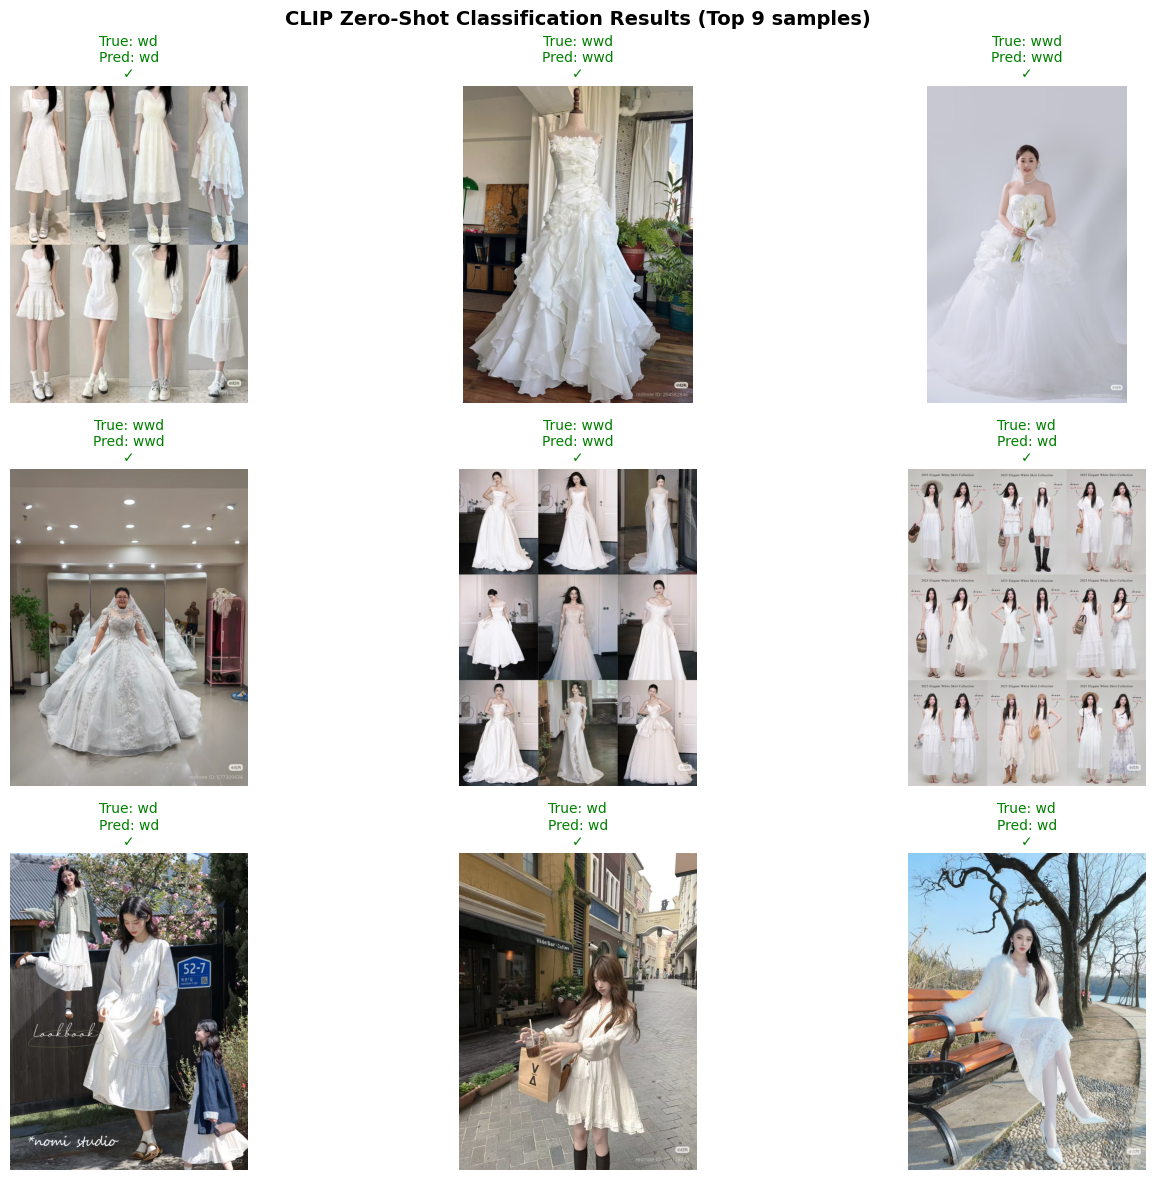

Showing confidence analysis...


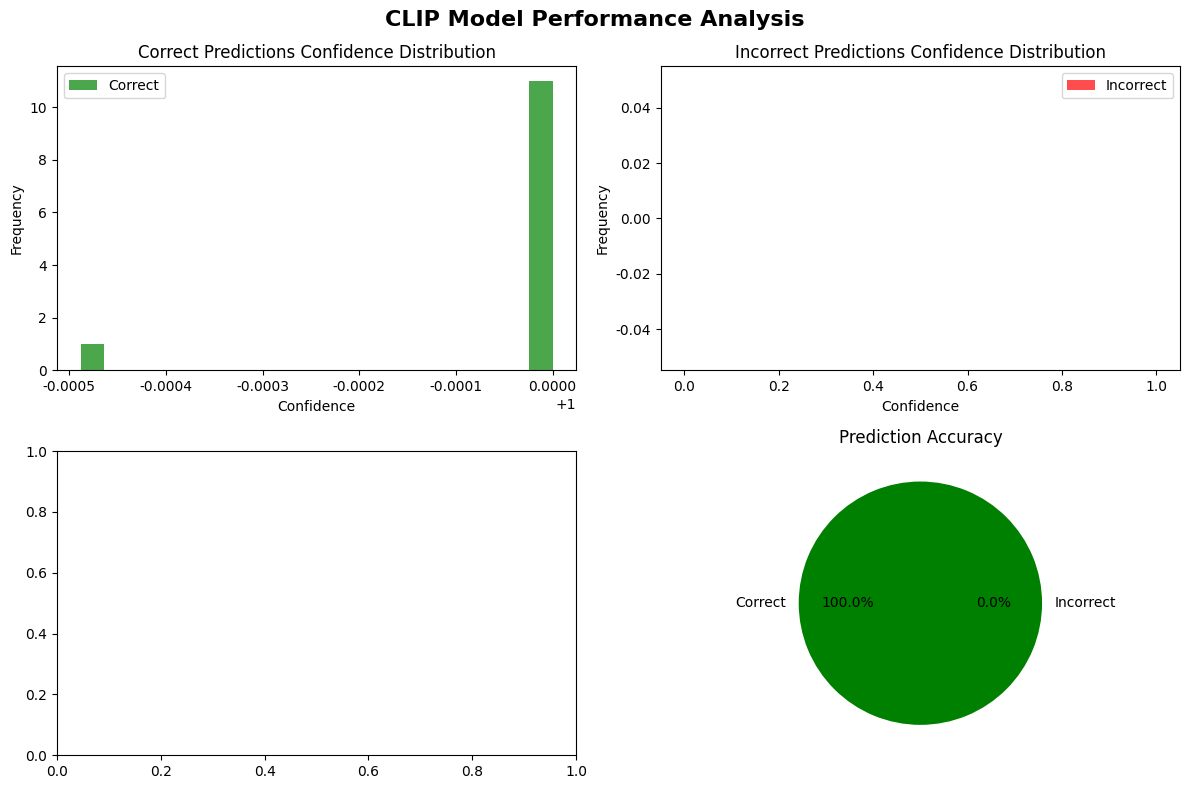

Showing error cases...
No error cases!


In [8]:
# ======== 6. Results Visualization ========
print(f"\n=== 6. Results Visualization ===")

def show_sample_results(results, num_show = 12):
    """Display sample test results"""
    plt.figure(figsize=(15, 12))
    
    for i in range(min(num_show, len(results))):
        result = results[i]
        
        plt.subplot(3, 3, i+1)
        
        # Get image
        sample_idx = result['index']
        image = test_samples[sample_idx]['image']
        
        plt.imshow(image)
        
        # Build title
        true_name = "wd" if result['true_label'] == 0 else "wwd"
        pred_name = "wd" if result['predicted_label'] == 0 else "wwd"
        status = "✓" if result['correct'] else "✗"
        
        title = f"True: {true_name}\nPred: {pred_name}\n{status}"
        color = 'green' if result['correct'] else 'red'
        
        plt.title(title, fontsize=10, color=color)
        plt.axis('off')
    
    plt.suptitle(f"CLIP Zero-Shot Classification Results (Top {num_show} samples)", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

def show_confidence_distribution():
    """Display confidence distribution"""
    plt.figure(figsize=(12, 8))
    
    # Correct predictions confidence
    plt.subplot(2, 2, 1)
    plt.hist(confidences['correct'], bins=20, alpha=0.7, color='green', label='Correct')
    plt.xlabel('Confidence')
    plt.ylabel('Frequency')
    plt.title('Correct Predictions Confidence Distribution')
    plt.legend()
    
    # Wrong predictions confidence
    plt.subplot(2, 2, 2)
    plt.hist(confidences['incorrect'], bins=20, alpha=0.7, color='red', label='Incorrect')
    plt.xlabel('Confidence')
    plt.ylabel('Frequency')
    plt.title('Incorrect Predictions Confidence Distribution')
    plt.legend()
    
    # Confidence comparison
    plt.subplot(2, 2, 3)
    if confidences['correct'] and confidences['incorrect']:
        plt.boxplot([confidences['correct'], confidences['incorrect']], 
                   labels=['Correct', 'Incorrect'])
        plt.ylabel('Confidence')
        plt.title('Confidence Comparison')
    
    # Accuracy pie chart
    plt.subplot(2, 2, 4)
    correct_count = len(confidences['correct'])
    incorrect_count = len(confidences['incorrect'])
    plt.pie([correct_count, incorrect_count], 
              labels=['Correct', 'Incorrect'], 
              colors=['green', 'red'],
              autopct='%1.1f%%')
    plt.title('Prediction Accuracy')
    
    plt.suptitle('CLIP Model Performance Analysis', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

def show_error_cases(results, num_show=6):
    """Display error cases"""
    error_cases = [r for r in results if not r['correct']]
    
    if not error_cases:
        print("No error cases!")
        return
    
    plt.figure(figsize=(15, 10))
    
    for i in range(min(num_show, len(error_cases))):
        result = error_cases[i]
        
        plt.subplot(2, 3, i+1)
        
        # Get image
        sample_idx = result['index']
        image = test_samples[sample_idx]['image']
        
        plt.imshow(image)
        
        # Build title
        true_name = "wd" if result['true_label'] == 0 else "wwd"
        pred_name = "wd" if result['predicted_label'] == 0 else "wwd"
        
        title = f"True: {true_name}\nPred: {pred_name}\nConf: {result['confidence']:.3f}"
        
        plt.title(title, fontsize=10, color='red')
        plt.axis('off')
    
    plt.suptitle(f'Error Case Analysis (Top {num_show})', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Display results
print("Showing sample test results...")
show_sample_results(results, 9)

print("Showing confidence analysis...")
show_confidence_distribution()

print("Showing error cases...")
show_error_cases(results, 6)


In [9]:
# ======== 7. Save Results ========
print(f"\n=== 7. Saving Test Results ===")

# Prepare save data
output_data = {
    'test_info': {
        'total_samples': total_samples,
        'correct_predictions': correct_predictions,
        'accuracy': accuracy,
        'accuracy_percent': accuracy * 100,
        'timestamp': time.strftime('%Y-%m-%d %H:%M:%S'),
        'model': 'ViT-B/32',
        'device': device
    },
    'category_performance': {
        'wd': {
            'total': wd_correct_total,
            'correct': wd_correct,
            'accuracy': wd_correct / wd_correct_total if wd_correct_total > 0 else 0
        },
        'wwd': {
            'total': wwd_total,
            'correct': wwd_correct,
            'accuracy': wwd_correct / wwd_total if wwd_total > 0 else 0
        }
    },
    'confidence_analysis': {
        'correct': {
            'mean': np.mean(confidences['correct']) if confidences['correct'] else 0,
            'std': np.std(confidences['correct']) if confidences['correct'] else 0,
            'min': np.min(confidences['correct']) if confidences['correct'] else 0,
            'max': np.max(confidences['correct']) if confidences['correct'] else 0
        },
        'incorrect': {
            'mean': np.mean(confidences['incorrect']) if confidences['incorrect'] else 0,
            'std': np.std(confidences['incorrect']) if confidences['incorrect'] else 0,
            'min': np.min(confidences['incorrect']) if confidences['incorrect'] else 0,
            'max': np.max(confidences['incorrect']) if confidences['incorrect'] else 0
        }
    },
    'detailed_results': results
}

# Save to file
output_filename = f'/mnt/disk1/suhan/STUDY/CLIP/CLIP/myexperiments/results_{int(time.time())}.json'
with open(output_filename, 'w', encoding='utf-8') as f:
    json.dump(output_data, f, ensure_ascii=False, indent=2)

print(f"Detailed results saved to: {output_filename}")


=== 7. Saving Test Results ===
Detailed results saved to: /mnt/disk1/suhan/STUDY/CLIP/CLIP/myexperiments/results_1764084355.json
